In [74]:
import numpy as np
import pandas as pd
import xarray as xr
from goes2go import GOES  
from pyproj import Proj
import numpy as np
import xarray as xr
from datetime import datetime, date
import re
from pathlib import Path
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

In [ ]:

# 1. Primero cargas el archivo (asegúrate de correr esta celda)
file_path = r"C:\Users\Brian OAQ\data\noaa-goes18\ABI-L2-MCMIPF\2026\153\14\OR_ABI-L2-MCMIPF-M6_G18_s20261531440223_e20261531449538_c20261531450013.nc"
ds = xr.open_dataset(file_path)

In [18]:
# Listar todas las variables de datos disponibles en el dataset
list(ds.data_vars)

['CMI_C01',
 'DQF_C01',
 'CMI_C02',
 'DQF_C02',
 'CMI_C03',
 'DQF_C03',
 'CMI_C04',
 'DQF_C04',
 'CMI_C05',
 'DQF_C05',
 'CMI_C06',
 'DQF_C06',
 'CMI_C07',
 'DQF_C07',
 'CMI_C08',
 'DQF_C08',
 'CMI_C09',
 'DQF_C09',
 'CMI_C10',
 'DQF_C10',
 'CMI_C11',
 'DQF_C11',
 'CMI_C12',
 'DQF_C12',
 'CMI_C13',
 'DQF_C13',
 'CMI_C14',
 'DQF_C14',
 'CMI_C15',
 'DQF_C15',
 'CMI_C16',
 'DQF_C16',
 'time_bounds',
 'goes_imager_projection',
 'y_image_bounds',
 'x_image_bounds',
 'nominal_satellite_subpoint_lat',
 'nominal_satellite_subpoint_lon',
 'nominal_satellite_height',
 'geospatial_lat_lon_extent',
 'outlier_pixel_count_C01',
 'min_reflectance_factor_C01',
 'max_reflectance_factor_C01',
 'mean_reflectance_factor_C01',
 'std_dev_reflectance_factor_C01',
 'outlier_pixel_count_C02',
 'min_reflectance_factor_C02',
 'max_reflectance_factor_C02',
 'mean_reflectance_factor_C02',
 'std_dev_reflectance_factor_C02',
 'outlier_pixel_count_C03',
 'min_reflectance_factor_C03',
 'max_reflectance_factor_C03',
 '

In [19]:
# Extraer metadatos de georreferenciación del satélite
proj_info = ds["goes_imager_projection"]

sat_h = proj_info.perspective_point_height
sat_lon = proj_info.longitude_of_projection_origin
sat_sweep = proj_info.sweep_angle_axis

In [22]:
# Configurar la proyección geostacionaria con los parámetros del satélite
p = Proj(proj="geos", h=sat_h, lon_0=sat_lon, sweep=sat_sweep)

# Coordenadas geográficas del Observatorio Astronómico de Quito (OAQ)
lon_oaq = -78.5025
lat_oaq = -0.2150

# Transformar coordenadas a la proyección del satélite (unidades de barrido)
x_oaq, y_oaq = p(lon_oaq, lat_oaq)

In [ ]:
# Convertir las coordenadas proyectadas (metros) a radianes de escaneo del satélite
# Usamos .item() para asegurar que la altura sea un valor numérico puro
sat_h_val = sat_h.item()

x_scan = x_oaq / sat_h_val
y_scan = y_oaq / sat_h_val


GOES x coordinate: 0.13913833088583843
GOES y coordinate: -0.0006122216753740704


In [25]:
# Encontrar los índices de los píxeles más cercanos
ix = np.abs(ds.x.values - x_scan).argmin()
iy = np.abs(ds.y.values - y_scan).argmin()

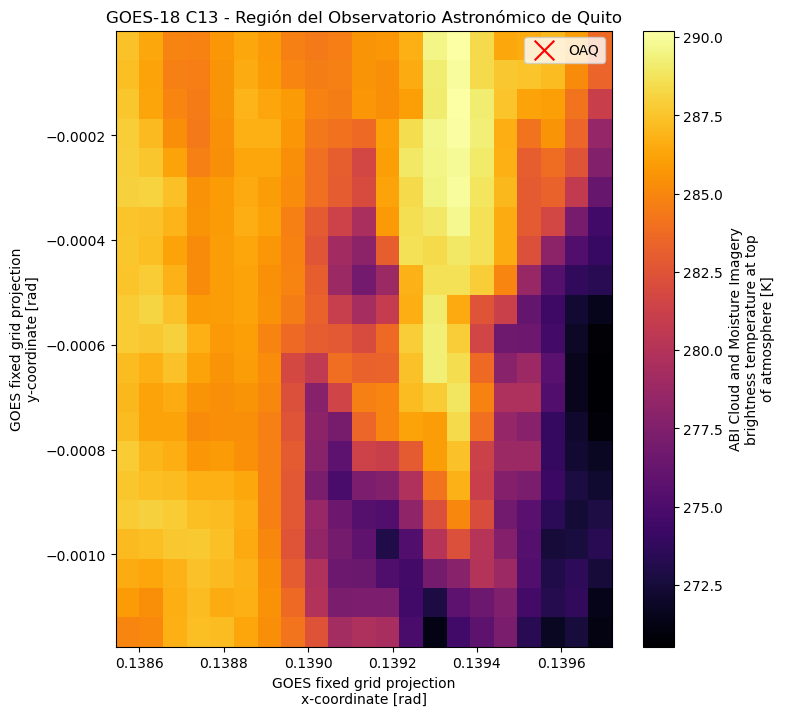

In [26]:
import matplotlib.pyplot as plt

# 1. Crear una ventana de 21x21 píxeles en la Banda 13 (Infrarrojo Térmico) alrededor del OAQ
window = ds["CMI_C13"].isel(y=slice(iy - 10, iy + 11), x=slice(ix - 10, ix + 11))

# 2. Visualización de control de calidad
plt.figure(figsize=(8, 8))
window.plot(cmap="inferno")  # Un mapa de color como 'inferno' va genial para infrarrojo

# Dibujar una 'X' en el centro exacto de nuestra ventana (píxel 10, 10)
plt.scatter(10, 10, color="red", marker="x", s=200, label="OAQ")

plt.title("GOES-18 C13 - Región del Observatorio Astronómico de Quito")
plt.legend()
plt.show()

In [27]:
# Crear una microventana de 5x5 píxeles alrededor del OAQ (Banda 13)
window5 = ds["CMI_C13"].isel(y=slice(iy - 2, iy + 3), x=slice(ix - 2, ix + 3))

# Extraer la matriz numérica de temperaturas de brillo para inspección
valores_temperatura = window5.values

In [28]:
# Calcular estadísticas descriptivas ignorando valores NaN
mean_val = window5.mean().item()
std_val = window5.std().item()
min_val = window5.min().item()
max_val = window5.max().item()

# Mostrar los resultados formateados
print(f"Estadísticas de la ventana (B13):\n{'—'*30}")
print(f"Mean : {mean_val:.2f}")
print(f"Std  : {std_val:.2f}")
print(f"Min  : {min_val:.2f}")
print(f"Max  : {max_val:.2f}")

Estadísticas de la ventana (B13):
——————————————————————————————
Mean : 282.77
Std  : 3.01
Min  : 276.87
Max  : 287.87


In [31]:
# Evaluar el impacto del tamaño de la ventana en las estadísticas del OAQ
ventanas_a_probar = [3, 5, 7, 9]

# Compilar los resultados en una lista de diccionarios
resultados_ventanas = [
    extract_oaq_c13_stats(ds, ix, iy, window=w) for w in ventanas_a_probar
]

# Convertir a DataFrame para una comparación visual e inmediata en el notebook
pd.DataFrame(resultados_ventanas).set_index("window")

,c13_mean,c13_std,c13_min,c13_max,n_pixels
window,,,,,
3,282.228363,1.463959,279.326416,283.873962,9
5,282.770264,3.011061,276.868256,287.868408,25
7,283.535370,3.441365,276.868256,289.281830,49
9,284.130371,3.483971,275.700653,289.712006,81


In [32]:
def extract_oaq_features(ds, ix, iy, window=5):
    """Extrae características multiespectrales (C13, C15, C16) y diferencias de

    temperatura de brillo (BTD) sobre el OAQ.
    """
    if window % 2 == 0:
        raise ValueError("window debe ser impar")

    half = window // 2
    channels = ["CMI_C13", "CMI_C15", "CMI_C16"]
    features = {}

    # 1. Extraer estadísticas para cada canal de interés
    for ch in channels:
        # Recorte optimizado en xarray para el canal actual
        subset = ds[ch].isel(
            y=slice(iy - half, iy + half + 1),
            x=slice(ix - half, ix + half + 1),
        )

        prefix = ch.lower()
        features[f"{prefix}_mean"] = float(subset.mean().item())
        features[f"{prefix}_std"] = float(subset.std().item())
        features[f"{prefix}_min"] = float(subset.min().item())
        features[f"{prefix}_max"] = float(subset.max().item())

    # 2. Calcular Diferencias de Temperatura de Brillo (BTD) para análisis de nubes
    features["btd_13_15"] = (
        features["cmi_c13_mean"] - features["cmi_c15_mean"]
    )
    features["btd_13_16"] = (
        features["cmi_c13_mean"] - features["cmi_c16_mean"]
    )
    features["btd_15_16"] = (
        features["cmi_c15_mean"] - features["cmi_c16_mean"]
    )

    return features

In [34]:
# Probar la extracción multiespectral completa para una ventana de 5x5 píxeles
features = extract_oaq_features(ds, ix, iy, window=5)

# Mostrar las variables en formato de serie vertical para una lectura rápida
pd.Series(features)

cmi_c13_mean    282.770264
cmi_c13_std       3.011061
cmi_c13_min     276.868256
cmi_c13_max     287.868408
cmi_c15_mean    279.893433
cmi_c15_std       2.217887
cmi_c15_min     275.347717
cmi_c15_max     283.388428
cmi_c16_mean    265.069946
cmi_c16_std       1.062814
cmi_c16_min     262.681610
cmi_c16_max     266.482239
btd_13_15         2.876831
btd_13_16        17.700317
btd_15_16        14.823486
dtype: float64

In [35]:
def process_goes_file(file_path, ix, iy, window=5):
    """Abre un archivo GOES local, extrae las métricas multiespectrales sobre el

    OAQ y añade la marca de tiempo (timestamp).
    """
    # Usamos 'with' para asegurar que el archivo se cierre correctamente después de leerlo
    with xr.open_dataset(file_path, engine="h5netcdf") as ds:
        # Extraer las variables calculadas (C13, C15, C16 y BTDs)
        features = extract_oaq_features(ds, ix, iy, window)

        # Extraer y convertir el tiempo central de la observación satelital
        timestamp = pd.to_datetime(ds.t.values)
        features["timestamp"] = timestamp

    return features

In [38]:
# Probar el procesamiento completo del archivo y verificar el diccionario con su timestamp
row = process_goes_file(file_path, ix, iy, window=5)

# Desplegar los resultados consolidados
pd.Series(row)

cmi_c13_mean                       282.770264
cmi_c13_std                          3.011061
cmi_c13_min                        276.868256
cmi_c13_max                        287.868408
cmi_c15_mean                       279.893433
cmi_c15_std                          2.217887
cmi_c15_min                        275.347717
cmi_c15_max                        283.388428
cmi_c16_mean                       265.069946
cmi_c16_std                          1.062814
cmi_c16_min                         262.68161
cmi_c16_max                        266.482239
btd_13_15                            2.876831
btd_13_16                           17.700317
btd_15_16                           14.823486
timestamp       2026-06-02 14:45:08.107645952
dtype: object

In [39]:
# Validar la conversión del formato de tiempo del satélite a Pandas
time_nativo = ds.t.values
time_convertido = pd.to_datetime(time_nativo)

print(f"Timestamp nativo (Xarray/NumPy): {time_nativo}")
print(f"Timestamp convertido (Pandas)  : {time_convertido}")

Timestamp nativo (Xarray/NumPy): 2026-06-02T14:45:08.107645952
Timestamp convertido (Pandas)  : 2026-06-02 14:45:08.107645952


In [40]:
from goes2go import GOES

# Inicializar la interfaz de descarga de GOES2go para el satélite GOES-18 (Disco Completo)
g = GOES(satellite="noaa-goes18", domain="F")

In [46]:
# Definir el rango de tiempo de 24 horas para la descarga de datos
start = datetime(2026, 4, 21, 5, 0)
end = datetime(2026, 4, 21, 6, 0)

In [47]:
# Descargar automáticamente todos los archivos GOES-18 para el rango de tiempo definido
files = g.timerange(start=start, end=end)

# Verificar cuántos archivos se descargaron e inspeccionar los primeros registros
print(f"Total de archivos descargados: {len(files)}")

📦 Finished downloading [6] files to [C:\Users\Brian OAQ\data\noaa-goes18\ABI-L2-MCMIPF].
Total de archivos descargados: 6


In [49]:
# Extraer la ruta local del primer archivo descargado para pruebas de integración
primer_archivo = files["file"].iloc[0]

print(f"Ruta del primer archivo listo para procesar:\n{primer_archivo}")

Ruta del primer archivo listo para procesar:
noaa-goes18/ABI-L2-MCMIPF/2026/111/05/OR_ABI-L2-MCMIPF-M6_G18_s20261110500202_e20261110509510_c20261110509583.nc


In [ ]:
# Buscar todos los archivos NetCDF en tu directorio local
goes_dir = Path(r"C:\Users\Brian OAQ\data\noaa-goes18\ABI-L2-MCMIPF")
all_files = sorted(goes_dir.rglob("*.nc"))

# 2. Extraer las fechas de los nombres de archivo usando expresiones regulares
# Los archivos GOES tienen el formato: ..._sYYYYJJJHHMMSS... donde JJJ es el día del año (Julian day)
registro_archivos = []

for filepath in all_files:
    # Capturamos el nombre del archivo
    filename = filepath.name

    # Buscamos el patrón del timestamp de inicio ('_s' seguido de 4 dígitos para el año y 3 para el día juliano)
    match = re.search(r"_s(\d{4})(\d{3})", filename)
    if match:
        anio = match.group(1)
        dia_juliano = match.group(2)

        # Convertir año y día juliano a una fecha legible (AAAA-MM-DD)
        fecha = pd.to_datetime(f"{anio}-{dia_juliano}", format="%Y-%j").date()

        registro_archivos.append(
            {"fecha": fecha, "ruta_completa": filepath, "archivo": filename}
        )

# 3. Convertir a DataFrame para agrupar y auditar
df_inventario = pd.DataFrame(registro_archivos)

# 4. Mostrar el reporte en pantalla
if not df_inventario.empty:
    reporte_fechas = df_inventario.groupby("fecha").size()
    print("=== INVENTARIO DE DATOS GOES EN DISCO ===")
    print(reporte_fechas)
    print(f"\nTotal de archivos listos en el sistema: {len(df_inventario)}")
else:
    print(
        "No se encontraron archivos en la ruta especificada. Verifica el directorio."
    )

=== INVENTARIO DE DATOS GOES EN DISCO ===
fecha
2026-04-21      6
2026-05-10    144
2026-06-02     18
dtype: int64

Total de archivos listos en el sistema: 168


In [54]:
# Inspeccionar los primeros 3 archivos del inventario para verificar rutas y nombres
df_inventario[["fecha", "archivo"]].head(3)

,fecha,archivo
0,2026-04-21,OR_ABI-L2-MCMIPF-M6_G18_s20261110500202_e20261...
1,2026-04-21,OR_ABI-L2-MCMIPF-M6_G18_s20261110510202_e20261...
2,2026-04-21,OR_ABI-L2-MCMIPF-M6_G18_s20261110520202_e20261...


In [80]:
# ==============================================================================
# CONFIGURACIÓN: Elige la fecha que deseas procesar del inventario
# ==============================================================================
# Opciones disponibles según tu disco: '2026-04-21', '2026-05-10', '2026-06-02'
fecha_objetivo = "2026-05-10"

# Convertir la cadena a tipo 'date' de Pandas para hacer el match perfecto
fecha_dt = pd.to_datetime(fecha_objetivo).date()

# Filtrar el inventario para quedarnos SOLO con los archivos de ese día
df_filtrado = df_inventario[df_inventario["fecha"] == fecha_dt]
archivos_a_procesar = df_filtrado["ruta_completa"].tolist()

print(f"=== CONTROL DE FILTRADO ===")
print(f"Fecha seleccionada : {fecha_objetivo}")
print(f"Archivos encontrados: {len(archivos_a_procesar)} archivos NetCDF.")

=== CONTROL DE FILTRADO ===
Fecha seleccionada : 2026-05-10
Archivos encontrados: 144 archivos NetCDF.


Construir el extractor temporal

In [81]:
# Mapear e iterar sobre el lote filtrado con indicador de progreso
rows = []

print(f"Iniciando procesamiento de {len(archivos_a_procesar)} archivos...")

for i, file in enumerate(archivos_a_procesar):
    # Monitorear el avance cada 20 archivos procesados
    if i % 20 == 0:
        print(f"Progreso: {i}/{len(archivos_a_procesar)} archivos completados.")

    try:
        # Pipeline optimizado (abre con h5netcdf, extrae características y cierra)
        row = process_goes_file(file, ix, iy, window=5)
        rows.append(row)

    except Exception as e:
        # Reportar fallos individuales si un NetCDF está corrupto
        print(f"\n Error al procesar el archivo: {file.name}")
        print(f"Detalle del error: {e}\n")

print(
    f"\n¡Procesamiento completado! Escenas procesadas con éxito: {len(rows)}/{len(archivos_a_procesar)}"
)

Iniciando procesamiento de 144 archivos...
Progreso: 0/144 archivos completados.

 Error al procesar el archivo: OR_ABI-L2-MCMIPF-M6_G18_s20261300000223_e20261300009543_c20261300010007.nc
Detalle del error: Unable to synchronously open file (file signature not found)


 Error al procesar el archivo: OR_ABI-L2-MCMIPF-M6_G18_s20261300010223_e20261300019538_c20261300020004.nc
Detalle del error: Unable to synchronously open file (file signature not found)


 Error al procesar el archivo: OR_ABI-L2-MCMIPF-M6_G18_s20261300020223_e20261300029532_c20261300030003.nc
Detalle del error: Unable to synchronously open file (file signature not found)


 Error al procesar el archivo: OR_ABI-L2-MCMIPF-M6_G18_s20261300030223_e20261300039544_c20261300040005.nc
Detalle del error: Unable to synchronously open file (file signature not found)


 Error al procesar el archivo: OR_ABI-L2-MCMIPF-M6_G18_s20261300040223_e20261300049544_c20261300050005.nc
Detalle del error: Unable to synchronously open file (file s

In [84]:
# Consolidar los resultados del día seleccionado
goes_df = pd.DataFrame(rows)

# Asegurar orden cronológico estricto
goes_df.sort_values("timestamp", inplace=True)
goes_df.reset_index(drop=True, inplace=True)

# Inspeccionar el resultado final listo para análisis
goes_df.head(2)

,cmi_c13_mean,cmi_c13_std,cmi_c13_min,cmi_c13_max,cmi_c15_mean,cmi_c15_std,cmi_c15_min,cmi_c15_max,cmi_c16_mean,cmi_c16_std,cmi_c16_min,cmi_c16_max,btd_13_15,btd_13_16,btd_15_16,timestamp
0,279.827850,2.392908,274.901764,283.751038,278.444885,1.970449,274.394745,281.601624,264.708618,1.026469,262.681610,266.316986,1.382965,15.119232,13.736267,2026-05-10 01:45:07.820574976
1,279.874542,2.378551,274.717407,283.812500,278.363892,2.123034,274.037384,281.839844,264.545563,1.255735,262.185852,266.482239,1.510651,15.328979,13.818329,2026-05-10 01:55:08.128487936


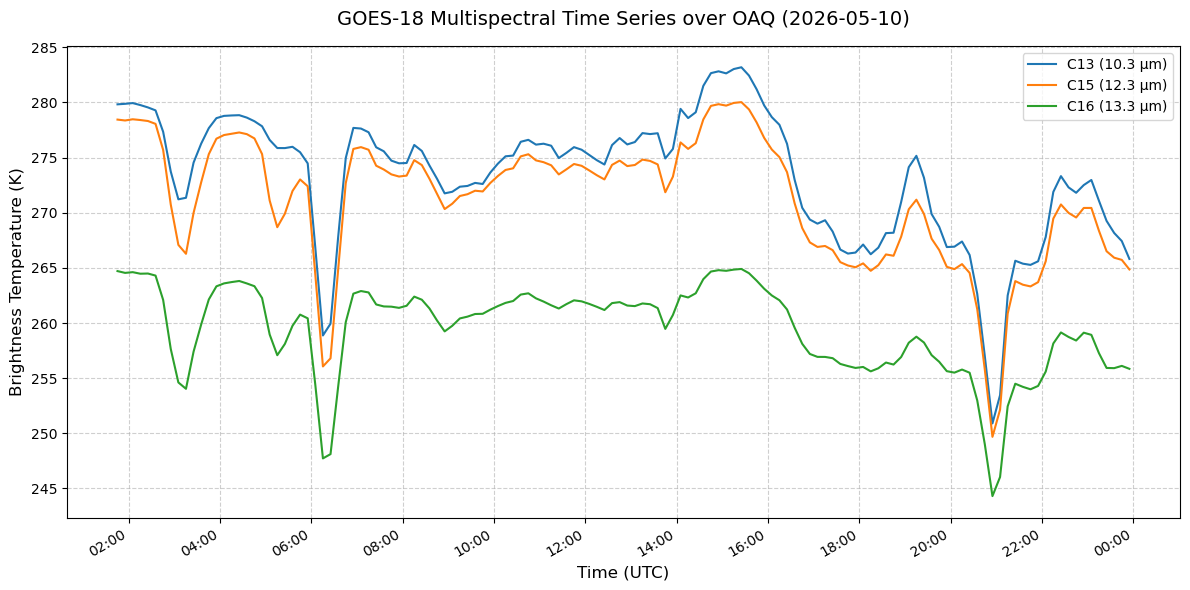

In [85]:
plt.figure(figsize=(12, 6))

# Graficar las series temporales de cada canal infrarrojo
plt.plot(
    goes_df["timestamp"], goes_df["cmi_c13_mean"], label="C13 (10.3 µm)", lw=1.5
)
plt.plot(
    goes_df["timestamp"], goes_df["cmi_c15_mean"], label="C15 (12.3 µm)", lw=1.5
)
plt.plot(
    goes_df["timestamp"], goes_df["cmi_c16_mean"], label="C16 (13.3 µm)", lw=1.5
)

# Dar formato profesional al eje del tiempo (X)
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))  # Marcas cada 2 horas
plt.gcf().autofmt_xdate()  # Rotar las fechas automáticamente para que no se traslapen

# Etiquetas, título y estilo
plt.title(
    f"GOES-18 Multispectral Time Series over OAQ ({fecha_objetivo})",
    fontsize=14,
    pad=15,
)
plt.xlabel("Time (UTC)", fontsize=12)
plt.ylabel("Brightness Temperature (K)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

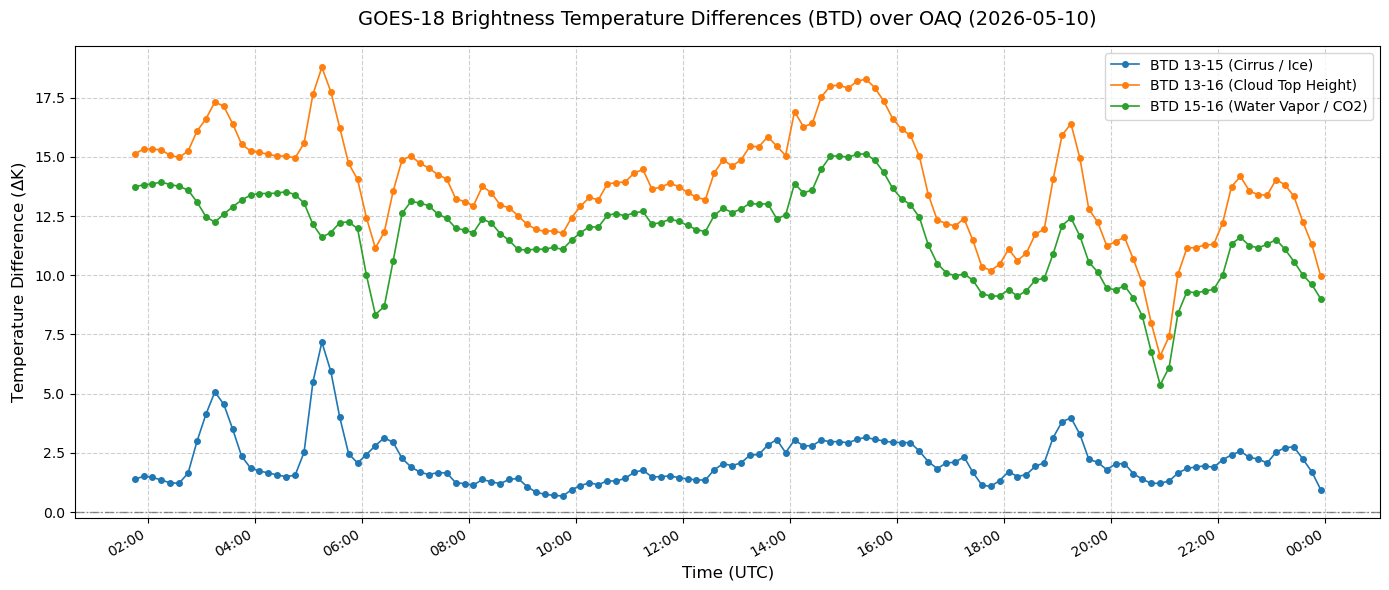

In [86]:
plt.figure(figsize=(14, 6))

# Graficar las diferencias térmicas con marcadores estilizados
plt.plot(
    goes_df["timestamp"],
    goes_df["btd_13_15"],
    marker="o",
    markersize=4,
    linewidth=1.2,
    label="BTD 13-15 (Cirrus / Ice)",
)
plt.plot(
    goes_df["timestamp"],
    goes_df["btd_13_16"],
    marker="o",
    markersize=4,
    linewidth=1.2,
    label="BTD 13-16 (Cloud Top Height)",
)
plt.plot(
    goes_df["timestamp"],
    goes_df["btd_15_16"],
    marker="o",
    markersize=4,
    linewidth=1.2,
    label="BTD 15-16 (Water Vapor / CO2)",
)

# Formatear el eje del tiempo (X) para que coincida con la gráfica anterior
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.gcf().autofmt_xdate()

# Etiquetas, título y estilo científico
plt.title(
    f"GOES-18 Brightness Temperature Differences (BTD) over OAQ ({fecha_objetivo})",
    fontsize=14,
    pad=15,
)
plt.xlabel("Time (UTC)", fontsize=12)
plt.ylabel("Temperature Difference ($\Delta$K)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="best", frameon=True)

# Añadir una línea de referencia en el cero para ver inversiones térmicas fácilmente
plt.axhline(0, color="black", linestyle="-.", alpha=0.4, linewidth=1)

plt.tight_layout()
plt.show()

In [87]:
# 1. Calcular la matriz de correlación para las variables del OAQ
goes_df[
    [
        "cmi_c13_mean",
        "cmi_c15_mean",
        "cmi_c16_mean",
        "btd_13_15",
        "btd_13_16",
        "btd_15_16"
    ]
].corr()

,cmi_c13_mean,cmi_c15_mean,cmi_c16_mean,btd_13_15,btd_13_16,btd_15_16
cmi_c13_mean,1.000000,0.984456,0.958311,0.187527,0.868785,0.981326
cmi_c15_mean,0.984456,1.000000,0.991246,0.012098,0.772386,0.958270
cmi_c16_mean,0.958311,0.991246,1.000000,-0.087799,0.691078,0.912140
btd_13_15,0.187527,0.012098,-0.087799,1.000000,0.626535,0.227665
btd_13_16,0.868785,0.772386,0.691078,0.626535,1.000000,0.901566
btd_15_16,0.981326,0.958270,0.912140,0.227665,0.901566,1.000000


In [88]:
# Analizar la variabilidad espacial (textura de las nubes) en la ventana del OAQ
goes_df[["cmi_c13_std", "cmi_c15_std", "cmi_c16_std"]].describe()

,cmi_c13_std,cmi_c15_std,cmi_c16_std
count,134.000000,134.000000,134.000000
mean,3.335614,3.036224,1.990659
std,1.782898,2.009895,1.735588
min,1.350665,1.023903,0.599376
25%,2.189449,1.869495,1.033986
50%,2.763747,2.422611,1.369760
75%,3.793095,3.221547,2.078117
max,12.225345,12.642979,9.981296


In [89]:
# Calcular la matriz de correlación para la variabilidad espacial (texturas)
matriz_corr_std = goes_df[
    ["cmi_c13_std", "cmi_c15_std", "cmi_c16_std"]
].corr()
matriz_corr_std

,cmi_c13_std,cmi_c15_std,cmi_c16_std
cmi_c13_std,1.000000,0.956276,0.908964
cmi_c15_std,0.956276,1.000000,0.987163
cmi_c16_std,0.908964,0.987163,1.000000


In [91]:
goes_df["hora_local"] = (
    goes_df["timestamp"]
    - pd.Timedelta(hours=5)
).dt.hour

In [92]:
ciclo = (
    goes_df
    .groupby("hora_local")
    [
        [
            "cmi_c13_mean",
            "cmi_c13_std",
            "btd_13_15",
            "btd_13_16"
        ]
    ]
    .mean()
)

ciclo

,cmi_c13_mean,cmi_c13_std,btd_13_15,btd_13_16
hora_local,,,,
0,275.710495,2.498473,4.528442,16.529510
1,267.675659,6.576118,2.581924,13.145383
2,275.939509,2.374029,1.506632,13.986450
3,274.228633,2.221972,1.301056,13.084539
4,272.607096,1.936947,0.834198,12.005005
5,275.661326,2.025114,1.261810,13.515483
6,275.730153,2.070364,1.569672,13.962911
7,275.577733,2.589416,1.651917,13.966176
8,276.445877,3.207018,2.553823,15.351364


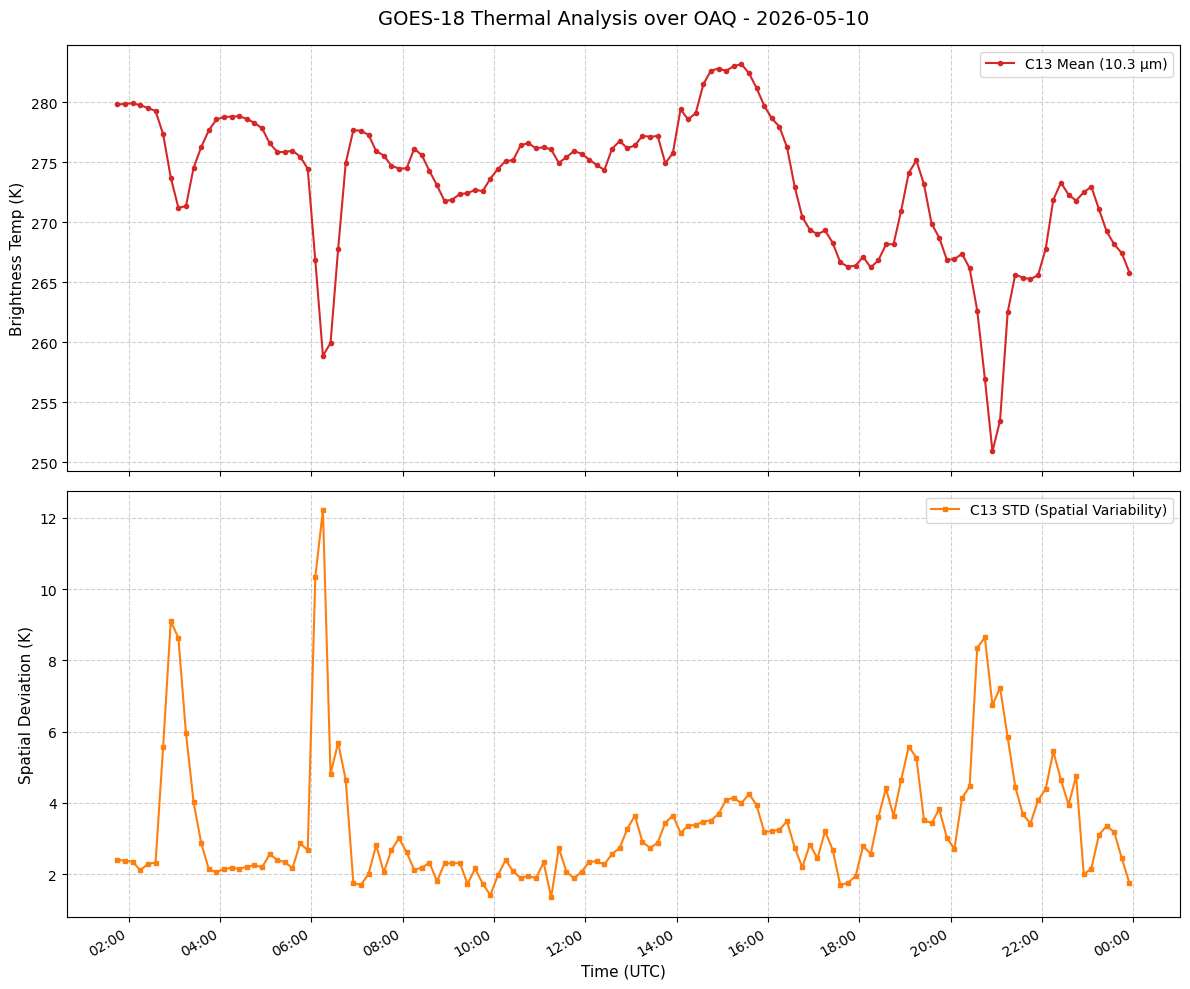

In [93]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

# Crear una figura con 2 subgráficos verticales (2 filas, 1 columna)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# ------------------------------------------------------------------------------
# Gráfico 1: Temperatura de Brillo Promedio (C13)
# ------------------------------------------------------------------------------
ax1.plot(
    goes_df["timestamp"],
    goes_df["cmi_c13_mean"],
    color="tab:red",
    linewidth=1.5,
    marker="o",
    markersize=3,
    label="C13 Mean (10.3 µm)",
)
ax1.set_ylabel("Brightness Temp (K)", fontsize=11)
ax1.set_title(
    f"GOES-18 Thermal Analysis over OAQ - {fecha_objetivo}",
    fontsize=14,
    pad=15,
)
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend(loc="upper right")

# ------------------------------------------------------------------------------
# Gráfico 2: Desviación Estándar Espacial (C13 Textura)
# ------------------------------------------------------------------------------
ax2.plot(
    goes_df["timestamp"],
    goes_df["cmi_c13_std"],
    color="tab:orange",
    linewidth=1.5,
    marker="s",
    markersize=3,
    label="C13 STD (Spatial Variability)",
)
ax2.set_xlabel("Time (UTC)", fontsize=11)
ax2.set_ylabel("Spatial Deviation (K)", fontsize=11)
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.legend(loc="upper right")

# Formatear el eje del tiempo (compartido por ambos subgráficos)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=2))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

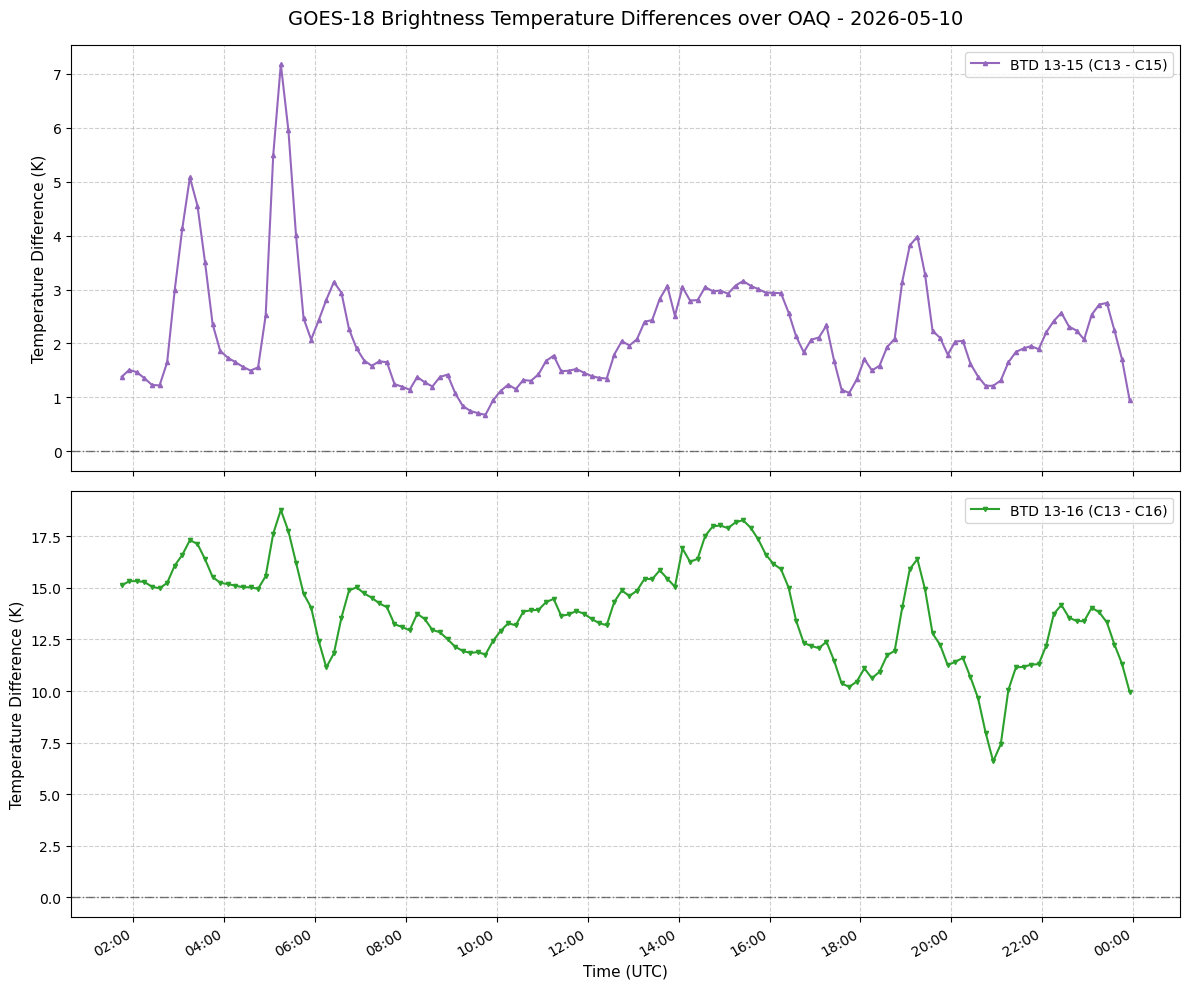

In [94]:
# Crear una figura con 2 subgráficos verticales para las BTD
fig, (ax3, ax4) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# ------------------------------------------------------------------------------
# Gráfico 3: BTD 13-15 (Firma de Cristales de Hielo / Cirrus)
# ------------------------------------------------------------------------------
ax3.plot(
    goes_df["timestamp"],
    goes_df["btd_13_15"],
    color="tab:purple",
    linewidth=1.5,
    marker="^",
    markersize=3,
    label="BTD 13-15 (C13 - C15)",
)
ax3.axhline(0, color="black", linestyle="-.", alpha=0.5, linewidth=1)
ax3.set_ylabel("Temperature Difference (K)", fontsize=11)
ax3.set_title(
    f"GOES-18 Brightness Temperature Differences over OAQ - {fecha_objetivo}",
    fontsize=14,
    pad=15,
)
ax3.grid(True, linestyle="--", alpha=0.6)
ax3.legend(loc="upper right")

# ------------------------------------------------------------------------------
# Gráfico 4: BTD 13-16 (Estimación de Altura de Tope de Nubes)
# ------------------------------------------------------------------------------
ax4.plot(
    goes_df["timestamp"],
    goes_df["btd_13_16"],
    color="tab:green",
    linewidth=1.5,
    marker="v",
    markersize=3,
    label="BTD 13-16 (C13 - C16)",
)
ax4.axhline(0, color="black", linestyle="-.", alpha=0.5, linewidth=1)
ax4.set_xlabel("Time (UTC)", fontsize=11)
ax4.set_ylabel("Temperature Difference (K)", fontsize=11)
ax4.grid(True, linestyle="--", alpha=0.6)
ax4.legend(loc="upper right")

# Formatear el eje del tiempo (compartido)
ax4.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax4.xaxis.set_major_locator(mdates.HourLocator(interval=2))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()